<a href="https://colab.research.google.com/github/josephine-dworkin/capstone-rbf-fd/blob/main/RBF_FD%5Bfinalcode%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
plt.style.use('bmh')
import pandas as pd
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix, eye, diags, identity
from scipy.sparse.linalg import svds
from scipy.sparse.linalg import spsolve, LinearOperator, onenormest
from scipy.sparse.linalg import splu
from numpy.linalg import solve, cond
from scipy.stats import norm

# RBF-FD Method

Initial parameters

In [2]:
K = 100 # strike price
T = 1 # time
r = 0.03
sigma = 0.15
M = 10 ** 6

S_min, S_max = 0.0, 400.0
N = 5000 # number of nodes
m = 9 # stencil size
k = 3 # polyharmonic spline degree
p = 4 # degree of polynomial augmentation
dt = 1 / N
Nt = int(T / dt)

Node generation and clustering

In [3]:
def uniform_nodes(N, S_min, S_max):
  # generates a simple uniform grid between Smin and Smax.
  return np.linspace(S_min, S_max, N)

def adapted_nodes(S_min, S_max, K, N, H=0.1):
  # generates sepcialised non-uniform nodes which are clustered around K by degree H
  K_hat = (K - S_min) / (S_max - S_min)
  z_min = np.arcsinh(-K_hat / H)
  z_max = np.arcsinh((1 - K_hat) / H)
  dz = (z_max - z_min) / N
  i = np.arange(N)
  z = z_min + i * dz
  # maps nodes in [0,1]
  x_hat = K_hat + H * np.sinh(z)
  # then maps to my actual computational domain between Smin and Smax
  S_nodes = S_min + (S_max - S_min) * x_hat
  return np.sort(S_nodes)

def clustered_strike_nodes(S_min, S_max, K, N, alpha=5.0):
  x = np.linspace(0.0, 1.0, N)
  K_hat = (K - S_min) / (S_max - S_min)
  S = np.empty_like(x)
  # Left of strike
  mask_left = x <= K_hat
  S[mask_left] = (K - (K - S_min) * np.sinh(alpha * (K_hat - x[mask_left]) / K_hat)
  / np.sinh(alpha))
  # Right of strike
  mask_right = x > K_hat
  S[mask_right] = (K + (S_max - K) * np.sinh(alpha * (x[mask_right] - K_hat) / (1.0 - K_hat))
  / np.sinh(alpha))
  # enforce exact endpoints
  S[0] = S_min
  S[-1] = S_max
  return S

Visualization of different node structures

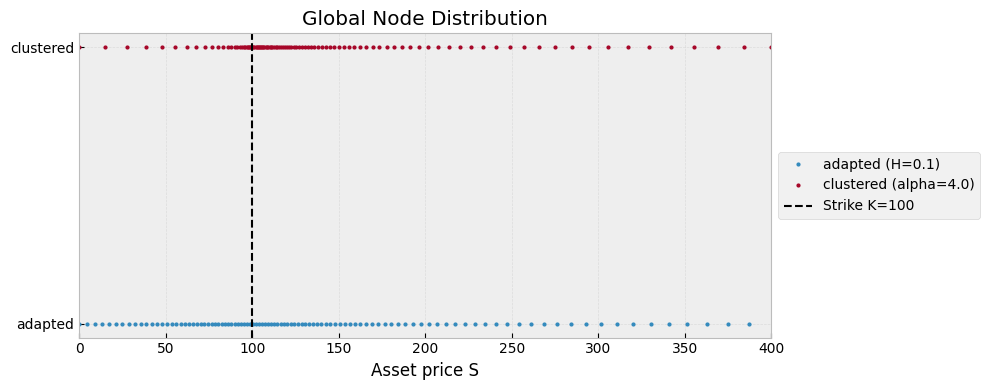

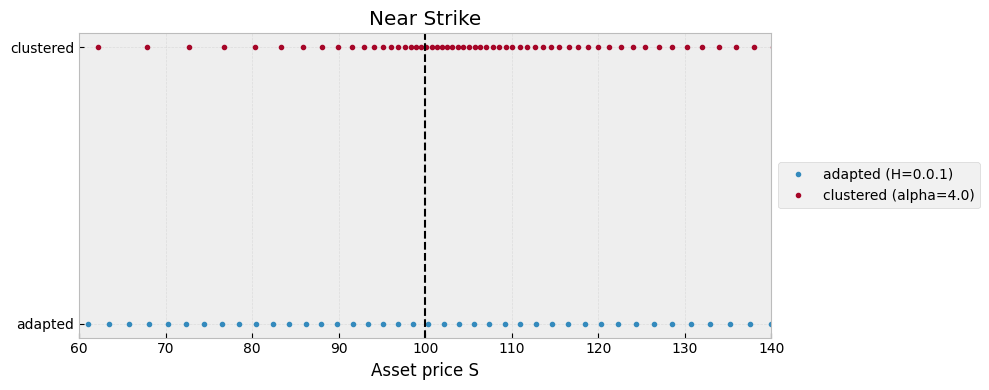

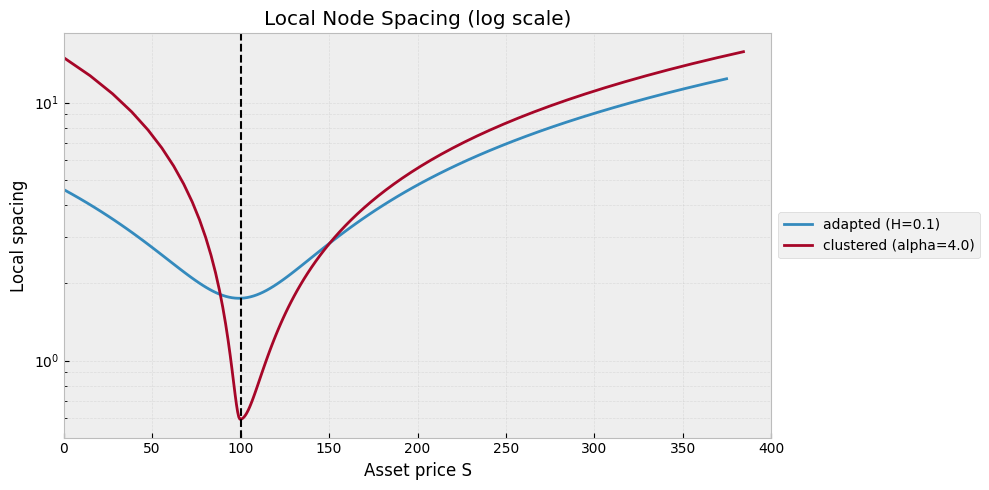

In [4]:
S_adapted = adapted_nodes(S_min, S_max, K, 100, H=0.1)
S_clustered = clustered_strike_nodes(S_min, S_max, K, 100, alpha=4.0)
S_uniform = uniform_nodes(N, S_min, S_max)

h_adapted = np.diff(S_adapted)
h_clustered = np.diff(S_clustered)

plt.figure(figsize=(10, 4))
plt.plot(S_adapted, np.zeros_like(S_adapted),
        'o', markersize=2, label="adapted (H=0.1)")
plt.plot(S_clustered, np.ones_like(S_clustered),
        'o', markersize=2, label="clustered (alpha=4.0)")
plt.axvline(K, color='k', linestyle='--', linewidth=1.5, label="Strike K=100")
plt.yticks([0, 1], ["adapted", "clustered"])
plt.xlabel("Asset price S")
plt.title("Global Node Distribution")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xlim(S_min, S_max)
plt.grid(alpha=0.3)
plt.show()

zoom_left = 60
zoom_right = 140

plt.figure(figsize=(10, 4))
plt.plot(S_adapted, np.zeros_like(S_adapted),
        'o', markersize=3, label="adapted (H=0.0.1)")
plt.plot(S_clustered, np.ones_like(S_clustered),
        'o', markersize=3, label="clustered (alpha=4.0)")
plt.axvline(K, color='k', linestyle='--', linewidth=1.5)
plt.yticks([0, 1], ["adapted", "clustered"])
plt.xlabel("Asset price S")
plt.title("Near Strike")
plt.xlim(zoom_left, zoom_right)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(S_adapted[:-1], h_adapted,
        label="adapted (H=0.1)")
plt.plot(S_clustered[:-1], h_clustered,
        label="clustered (alpha=4.0)")
plt.axvline(K, color='k', linestyle='--', linewidth=1.5)
plt.yscale("log")
plt.xlabel("Asset price S")
plt.ylabel("Local spacing")
plt.title("Local Node Spacing (log scale)")
plt.xlim(S_min, S_max)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

Building stencils around each node

In [5]:
def build_stencils(S_nodes, m):
  # builds stencils of dimension m around each node, consisting of the m-1 nearest nodes and itself
  S_nodes = np.asarray(S_nodes)
  tree = cKDTree(S_nodes[:, None])
  _, stencils = tree.query(S_nodes[:, None], k=m)
  return stencils

Constructing local RBF-FD interpolation matrices

In [6]:
def phs(r, k):
  # defines a polyharmonic spline for k odd
  return np.power(r, k)

def phs_d1(h, k):
  # defines the first derivative
  r = np.abs(h)
  return k * h * np.power(r, max(k - 2, 0))

def phs_d2(h, k):
  # defines the second derivative
  r = np.abs(h)
  return k * (k - 1) * np.power(r, max(k - 2, 0))

def poly_matrix_1D(x_local, k):
  # constructs a one-dimensional matrix with both derivatives
  return np.vstack([x_local ** d for d in range(k + 1)]).T

def build_augmented_matrix_and_rhs(x_local, x_center, k, p,
                                   enforce_constant=True, deriv_order=1):

  # Enforce_constant=False means I do not have an extra unknown/ constraint that enforces
  # the weights to sum to 0. I do not need this extra column because my polynomial augmentation
  # means the matrix includes the constant term "1" as the first column.
  m = x_local.size
  P = poly_matrix_1D(x_local, p)  # (m, p)
  p = P.shape[1]
  c = 1 if enforce_constant else 0

  # Phi matrix
  R = np.abs(x_local[:, None] - x_local[None, :])   # (m,m)
  Phi = phs(R, k)

  # Top-left block is Phi
  # Build top-right polynomial block and optional constant column
  if enforce_constant:
      P_aug = np.hstack([P, np.ones((m,1))])
  else:
      P_aug = P

  # Build bottom block
  bottom_left = P_aug.T
  bottom_right = np.zeros((p + c, p + c))
  # Assemble augmented matrix
  top = np.hstack([Phi, P_aug])
  bottom = np.hstack([bottom_left, bottom_right])
  A_aug = np.vstack([top, bottom])
  # Final augmented matrix has dimensions (m+p+c, m+p+c)

  # Build RHS
  # Top part: operator applied to phi centered at each x_local, evaluated at x_center
  h = x_center - x_local
  if deriv_order == 1:
      rhs_top = np.array([phs_d1(hj, k) for hj in h])
  elif deriv_order == 2:
      rhs_top = np.array([phs_d2(hj, k) for hj in h])
  else:
      raise ValueError("deriv_order must be 1 or 2")

  # Bottom part: derivative of polynomial basis at x_center
  rhs_poly = np.zeros(p + c)
  # For 1D: derivative of x^d is d * x^(d-1)
  if deriv_order == 1:
      for d in range(1, p):
          rhs_poly[d] = d * (x_center ** (d - 1))
      # if constant enforcement present, its RHS bottom entry is 0
  elif deriv_order == 2:
      for d in range(2, p):
          rhs_poly[d] = d * (d-1) * (x_center ** (d - 2))
  rhs = np.concatenate([rhs_top, rhs_poly])

  return A_aug, rhs, m, p, c

Computing local weights

In [7]:
def compute_local_weights(x_local, x_center, k, p, enforce_constant=False,
                          deriv_order=1, regularize=1e-13):
  # solves the augmented matrix around each node to calculate weights, computing condition numbers of each of these matrices
  A_aug, rhs, m, p, c = build_augmented_matrix_and_rhs(
      x_local, x_center, k, p, enforce_constant=enforce_constant,
      deriv_order=deriv_order)

  # Tikhonov regularization
  if regularize:
      A_aug = A_aug.copy()
      A_aug[:m, :m] += np.eye(m) * regularize

  sol = solve(A_aug, rhs)
  weights = sol[:m]
  try:
    condA = cond(A_aug)
  except Exception:
    condA = np.inf
  return weights, condA

Stencil scaling

In [8]:
def compute_local_weights_scaled(x_local, x_center, k, p,
                                 enforce_constant=False,
                                 deriv_order=1,
                                 regularize=False):
  # local weights are scaled such that within each stencil, the distance of the node furthest from the central node is 1
  # distance from center
  r = np.abs(x_local - x_center)
  # scaling factor: max distance from center
  h = np.max(r)
  # scaled stencil inside [−1, 1]
  x_scaled = (x_local - x_center) / h
  x_center_scaled = 0.0   # set center to zero after scaling

  A_aug, rhs, m, p, c = build_augmented_matrix_and_rhs(
      x_scaled, x_center_scaled, k, p,
      enforce_constant=enforce_constant,
      deriv_order=deriv_order
  )
  # Tikhonov regularization
  if regularize:
        A_aug = A_aug.copy()
        A_aug[:m, :m] += np.eye(m) * regularize
  # solve system for scaled derivative
  sol = solve(A_aug, rhs)
  weights_scaled = sol[:m]
  # derivative rescales by h^{-d}
  scale_factor = h**(-deriv_order)
  weights = weights_scaled * scale_factor

  try:
      condA = cond(A_aug)
  except Exception:
      condA = np.inf

  return weights, condA

Assembling sparse global spatial operator

In [9]:
def build_global_derivative_matrices(S_nodes, m, k, p, sigma, r,
                                enforce_constant=False,
                                cond_warn=1e10):
  # local weight matrices assembled into global derivatice matrix which may then be solved for a linear operator
  # bc_nodes sets the indices to treat as Dirichlet rows (the boundary nodes)
  # for my Black-Scholes equations, i need a first derivative and a second derivative matrix
  N = S_nodes.size
  rows, cols, data_D1, data_D2 = [], [], [], []
  rowsA, colsA, dataA = [], [], []

  cond_list = np.zeros(N)

  stencils = build_stencils(S_nodes, m)

  for i in range(N):
    idx = stencils[i]
    x_local = S_nodes[idx]
    x_center = S_nodes[i]

    w1, cond1 = compute_local_weights_scaled(x_local, x_center,
                                      k, p, enforce_constant=enforce_constant, deriv_order=1)
    w2, cond2 = compute_local_weights_scaled(x_local, x_center,
                                      k, p, enforce_constant=enforce_constant, deriv_order=2)

    cond_list[i] = max(cond1, cond2)

    if cond_list[i] > cond_warn:
      print(f"stencil {[i]} cond ~ {cond_list[i]:.2e}")

    for local_j, j in enumerate(idx):
      # store D1 and D2 entries
      rows.append(i); cols.append(j)
      data_D1.append(w1[local_j])
      data_D2.append(w2[local_j])

  D1 = csr_matrix((data_D1, (rows, cols)), shape=(N, N))
  D2 = csr_matrix((data_D2, (rows, cols)), shape=(N, N))

  return D1.tocsr(), D2.tocsr(), stencils, cond_list

Constructing Black-Scholes operator

In [10]:
def construct_linear_operator(S_nodes, m, k, p, sigma, r, enforce_constant=False):
  # first derivative matrix, second derivative matrix, and final spatial linear operator carefully computed
  D1, D2, stencils, cond_local = build_global_derivative_matrices(S_nodes, m, k, p, sigma, r, enforce_constant=enforce_constant)
  N = len(S_nodes)
  S = S_nodes
  I = identity(N, format="csr")
  S_diag = diags(S)
  S_squared_diag = diags(S**2)

  L = (0.5 * sigma ** 2 * S_squared_diag @ D2 + r * S_diag @ D1 - r * I)

  return D1, D2, L, stencils, cond_local

Dirichlet boundary conditions

In [11]:
def boundary_values_call_1d(S_nodes, t, T, r, K):
  # since pdes are on a potentially infinite domain, i must enforce the analytic solution at my boundaries
  # this function computes the analytic solutions at Smin and Smax
  S_max = S_nodes[-1]

  g_left = 0.0
  g_right = S_max - K * np.exp(-r * (T - t))

  return g_left, g_right

def enforce_dirichlet_rows(A, rhs, bc_idx, bc_vals):
  # and this one enforce them unto my linear operator
  A = A.tolil()
  for idx, g in zip(bc_idx, bc_vals):
    A.rows[idx] = [idx]
    A.data[idx] = [1.0]
    rhs[idx] = g

  return A.tocsr(), rhs

Condition number of golbal linear operator

In [17]:
import numpy as np
from scipy.sparse.linalg import eigs, spsolve, LinearOperator, onenormest
from scipy.sparse import issparse
from scipy.linalg import svdvals, eigvals

"""def compute_global_condition_number(L):
  # missing code to construct appropriate time discretization matrix A
  # estimate using 1-norm and approximate inverse
  if issparse(A):
    N = A.shape[0]
    x = np.random.rand(N)
    y = A @ x
    A1 = np.linalg.norm(A.toarray(), 1)
    Ainv1 = np.linalg.norm(spsolve(A, x), 1) / np.linalg.norm(x, 1)
  else:
    N = A.shape[0]
    x = np.random.rand(N)
    y = A @ x
    A1 = np.linalg.norm(A, 1)
    Ainv1 = np.linalg.norm(np.linalg.solve(A, x), 1) / np.linalg.norm(x, 1)
  cond_est = A1 * Ainv1
  return float(cond_est) """

def compute_global_condition_number(L):
    # Construct BDF-2 time discretization matrix
    if issparse(L):
        I = identity(L.shape[0], format=L.format)
        A = (3.0 / (2.0 * dt)) * I - L
    else:
        I = np.eye(L.shape[0])
        A = (3.0 / (2.0 * dt)) * I - L

    # estimate using 1-norm and approximate inverse
    N = A.shape[0]
    x = np.random.rand(N)

    if issparse(A):
        A1 = np.linalg.norm(A.toarray(), 1)
        Ainv1 = np.linalg.norm(spsolve(A, x), 1) / np.linalg.norm(x, 1)
    else:
        A1 = np.linalg.norm(A, 1)
        Ainv1 = np.linalg.norm(np.linalg.solve(A, x), 1) / np.linalg.norm(x, 1)

    cond_est = A1 * Ainv1
    return float(cond_est)

Time Discretization using BDF-2

In [13]:
def solve_bdf2(
  S_nodes, m, k, p,
  sigma, r, K, T,
  enforce_constant=False,
  bc_nodes=(0, -1),
  cond_warn=1e10,
  verbose=True
):
  # Black-Scholes backward in time so I compute time discretization
  N = S_nodes.size
  dt = 1 / N
  Nt = int(np.ceil(T / dt))

  D1, D2, L, stencils, cond_local = construct_linear_operator(
      S_nodes, m, k, p, sigma, r, enforce_constant=enforce_constant)

  cond_global = compute_global_condition_number(L)

  I = identity(N, format="csr")

  # terminal condition (payoff)
  V0_term = np.maximum(S_nodes - K, 0.0)

  # boundary indices
  bc_idx = [(b if b >= 0 else N + b) for b in bc_nodes]

  if verbose:
      print(f"BDF-2: Nt={Nt}, dt={dt} (Backward Euler startup)")
      print(f"Global condition number (L): {cond_global}")

  # backward Euler for first time step:
  BE_left = (I / dt - L).tocsr()
  rhs_BE = V0_term / dt

  t1 = T - dt
  g1_left, g1_right = boundary_values_call_1d(S_nodes, t1, T, r, K)
  bc_vals1 = [g1_left, g1_right]

  BE_left, rhs_BE = enforce_dirichlet_rows(
      BE_left.copy(), rhs_BE, bc_idx, [g1_left, g1_right]
  )

  V_prev = V0_term.copy()   # V^0
  V_curr = spsolve(BE_left, rhs_BE)  # V^1

  # implementing BDF-2
  BDF2_left_base = (3.0 / (2.0 * dt)) * I - L
  BDF2_left_base = BDF2_left_base.tocsr()

  for n in range(1, Nt):
      t_next = T - (n + 1) * dt

      rhs = (
          (4.0 / (2.0 * dt)) * V_curr
          - (1.0 / (2.0 * dt)) * V_prev
      )

      g_left, g_right = boundary_values_call_1d(S_nodes, t_next, T, r, K)

      BDF2_left, rhs = enforce_dirichlet_rows(
          BDF2_left_base.copy(), rhs, bc_idx, [g_left, g_right]
      )

      V_next = spsolve(BDF2_left, rhs)

      V_prev[:] = V_curr
      V_curr[:] = V_next

  # solution at t = 0
  V0 = V_curr

  # solving for the Greeks
  Delta = D1 @ V0
  Gamma = D2 @ V0

  # Theta from PDE:  V_t = A V   →   Theta = -V_t
  Theta = -L @ V0

  # condition number estimate
  return {
      "V0": V0,
      "Delta": Delta,
      "Gamma": Gamma,
      "Theta": Theta,
      "cond_local": cond_local,
      "cond_global": cond_global
      }

# Numerical experiments

Generating analytic solutions

In [14]:
def black_scholes_exact(S, K, T, t, r, sigma, option="call"):
    S = np.asarray(S, dtype=float)
    tau = np.maximum(T - t, 1e-14)  # avoid division by zero

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    if option == "call":
        V = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    elif option == "put":
        V = K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option must be 'call' or 'put'")

    return V

def delta_exact(S, K, T, t, r, sigma, option="call"):
    S = np.asarray(S, dtype=float)
    tau = np.maximum(T - t, 1e-14)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))

    if option == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1

def gamma_exact(S, K, T, t, r, sigma):
    S = np.asarray(S, dtype=float)
    tau = np.maximum(T - t, 1e-14)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))

    return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

def theta_exact(S, K, T, t, r, sigma, option="call"):
    S = np.asarray(S, dtype=float)
    tau = np.maximum(T - t, 1e-14)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    term1 = - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(tau))

    if option == "call":
        term2 = - r * K * np.exp(-r * tau) * norm.cdf(d2)
    else:
        term2 = + r * K * np.exp(-r * tau) * norm.cdf(-d2)

    return term1 + term2


Functions for numerical experiments

In [15]:
def run_experiment_with_node_family(*, node_family, H, node_params, solver_params, verbose=False):
    S_min = node_params["S_min"]
    S_max = node_params["S_max"]
    K_loc = node_params["K"]
    N_loc = node_params["N"]

    if node_family == "adapted (H=0.1)":
        S_nodes = adapted_nodes(S_min, S_max, K_loc, N_loc, H=0.1)
    elif node_family == "adapted (H=0.05)":
        S_nodes = adapted_nodes(S_min, S_max, K_loc, N_loc, H=0.05)
    elif node_family == "uniform":
        S_nodes = uniform_nodes(N_loc, S_min, S_max)
    elif node_family == "clustered (alpha=4.0)":
        S_nodes = clustered_strike_nodes(S_min, S_max, K_loc, N_loc, alpha=4.0)
    elif node_family == "clustered (alpha=2.0)":
        S_nodes = clustered_strike_nodes(S_min, S_max, K_loc, N_loc, alpha=2.0)
    else:
        raise ValueError(f"Unknown node_family: {node_family}")

    results = solve_bdf2(
        S_nodes=S_nodes,
        verbose=verbose,
        **solver_params
    )
    results["S_nodes"] = S_nodes
    results["H"] = H
    results["node_family"] = node_family
    return results


def compute_price_error_norms(results, *, K, T, r, sigma):
    S_nodes = results["S_nodes"]
    V_num = results["V0"]
    V_ex = black_scholes_exact(S_nodes, K, T, t=0.0, r=r, sigma=sigma)
    err = np.abs(V_num - V_ex)
    # ignore boundaries for fair comparison
    core = err[1:-1] if err.size > 2 else err
    return float(np.max(core)), float(np.sqrt(np.mean(core**2)))


def compute_observed_rates(df, error_col="price_Linf"):
    rows = []

    group_cols = ["node_family"]
    if "p" in df.columns:
        group_cols.append("p")

    grouped = df.sort_values("N").groupby(group_cols)

    for keys, sub in grouped:
        sub = sub.sort_values("N")

        N_vals = sub["N"].values
        err_vals = sub[error_col].values

        for i in range(1, len(N_vals)):
            N1, N2 = N_vals[i-1], N_vals[i]
            e1, e2 = err_vals[i-1], err_vals[i]

            slope = np.log(e2 / e1) / np.log(N1 / N2)

            row = {
                "N1": N1,
                "N2": N2,
                "observed_rate": slope,
            }

            if isinstance(keys, tuple):
                for col, val in zip(group_cols, keys):
                    row[col] = val
            else:
                row[group_cols[0]] = keys

            rows.append(row)

    return pd.DataFrame(rows)

def collect_local_condition_numbers(S_nodes, m, k, p):
    N = S_nodes.size
    stencils = build_stencils(S_nodes, m)
    cond_d1 = np.zeros(N)
    cond_d2 = np.zeros(N)

    for i in range(N):
        idx = stencils[i]
        x_local = S_nodes[idx]
        x_center = S_nodes[i]

        _, cond1 = compute_local_weights_scaled(
            x_local, x_center, k, p, deriv_order=1
        )
        _, cond2 = compute_local_weights_scaled(
            x_local, x_center, k, p, deriv_order=2
        )

        cond_d1[i] = cond1
        cond_d2[i] = cond2

    return cond_d1, cond_d2


Node layouts

In [18]:
N_values_cmp = [4000, 6000]
rows_N_cmp = []
H_fixed = 0.1


node_params = dict(
    S_min=0.0,
    S_max=400.0,
    N=N,
    K=K
)

solver_params = dict(
    m=9,
    k=3,
    p=4,
    sigma=sigma,
    r=r,
    K=K,
    T=T,
    enforce_constant=False,
    bc_nodes=(0, -1),
)

for N in N_values_cmp:
    local_node_params = dict(node_params)
    local_node_params["N"] = N

    for fam in ["adapted (H=0.1)", "adapted (H=0.05)", "uniform", "clustered (alpha=4.0)", "clustered (alpha=2.0)"]:
        res = run_experiment_with_node_family(
            node_family=fam,
            H=H_fixed,
            node_params=local_node_params,
            solver_params=solver_params,
            verbose=False,
        )
        price_Linf, price_L2 = compute_price_error_norms(res, K=K, T=T, r=r, sigma=sigma)
        rows_N_cmp.append({
            "node_family": fam,
            "N": N,
            "price_Linf": price_Linf,
            "price_L2": price_L2,
            "cond_median": float(np.median(res["cond_local"])),
            "cond_max": float(np.max(res["cond_local"])),
            "cond_global": float(res["cond_global"])
        })

N_fixed = node_params["N"]
H_fixed_plot = 0.1

node_families = [
    ("adapted (H=0.1)", adapted_nodes(node_params["S_min"], node_params["S_max"], node_params["K"], N_fixed, H=0.1)),
    ("adapted (H=0.0.5)", adapted_nodes(node_params["S_min"], node_params["S_max"], node_params["K"], N_fixed, H=0.05)),
    ("uniform", uniform_nodes(N_fixed, node_params["S_min"], node_params["S_max"])),
    ("clustered (alpha=4.0)", clustered_strike_nodes(node_params["S_min"], node_params["S_max"], node_params["K"], N_fixed, alpha=4.0)),
    ("clustered (alpha=2.0)", clustered_strike_nodes(node_params["S_min"], node_params["S_max"], node_params["K"], N_fixed, alpha=2.0)),
]

df_N_cmp = pd.DataFrame(rows_N_cmp)

/tmp/ipykernel_1755/2940955345.py:5: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


In [1]:
plt.figure(figsize=(8, 5))
for fam, marker in [("adapted (H=0.1)", "o-"), ("adapted (H=0.05)", "o-"), ("uniform", "s--"), ("clustered (alpha=4.0)", "^:"), ("clustered (alpha=2.0)", "^:")]:
    sub = df_N_cmp[df_N_cmp["node_family"] == fam].sort_values("N")
    plt.loglog(sub["N"], sub["price_Linf"], marker, label=f"{fam}")

plt.xlabel("N")
plt.ylabel("Price error $L^\\infty$")
plt.title("Convergence vs N for various nodes")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for fam, marker in [("adapted (H=0.1)", "o-"), ("adapted (H=0.05)", "o-"), ("uniform", "s--"), ("clustered (alpha=4.0)", "^:"), ("clustered (alpha=2.0)", "^:")]:
    sub = df_N_cmp[df_N_cmp["node_family"] == fam].sort_values("N")
    plt.semilogy(sub["N"], sub["cond_median"], marker, label=f"{fam}")

plt.xlabel("N")
plt.ylabel("Median local condition number")
plt.title("Local conditioning vs N for various nodes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for fam, marker in [("adapted (H=0.1)", "o-"), ("adapted (H=0.05)", "o-"), ("uniform", "s--"), ("clustered (alpha=4.0)", "^:"), ("clustered (alpha=2.0)", "^:")]:
    sub = df_N_cmp[df_N_cmp["node_family"] == fam].sort_values("N")
    plt.semilogy(sub["N"], sub["cond_global"], marker, label=f"{fam}")

plt.xlabel("N")
plt.ylabel("Global condition number of L")
plt.title("Global conditioning vs N for various nodes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

NameError: name 'plt' is not defined

Polynomial augmentation and stencil size

In [ ]:
p_values = [2, 3, 4, 5]
m_values = [5, 7, 9, 11]
N_values = [500, 1000, 2000, 4000]

node_params = dict(
    S_min=0.0,
    S_max=400.0,
    N=N,
    K=K
)

solver_params = dict(
    m=9,
    k=k,
    p=2,
    sigma=sigma,
    r=r,
    K=K,
    T=T,
    enforce_constant=False,
    bc_nodes=(0, -1),
)

rows_p_study = []

for p_val in p_values:
  idx = p_values.index(p_val)
  m_val = m_values[idx]
  for N in N_values:

    local_node_params = dict(node_params)
    local_node_params["N"] = N

    for fam in ["adapted", "clustered", "uniform"]:

      # Build nodes
      if fam == "adapted":
        S_nodes_local = adapted_nodes(
          node_params["S_min"],
          node_params["S_max"],
          node_params["K"],
          N,
          H=0.1
        )
      elif fam == "clustered":
        S_nodes_local = clustered_strike_nodes(
          node_params["S_min"],
          node_params["S_max"],
          node_params["K"],
          N,
          alpha=4.0
        )
      elif fam == "uniform":
        S_nodes_local = uniform_nodes(
          N,
          node_params["S_min"],
          node_params["S_max"]
        )

      # Update solver params with new p
      local_solver_params = dict(solver_params)
      local_solver_params["p"] = p_val
      local_solver_params["m"] = m_val

      res = solve_bdf2(
          S_nodes=S_nodes_local,
          verbose=False,
          **local_solver_params
          )

      # Compute error
      V_num = res["V0"]
      V_ex = black_scholes_exact(
          S_nodes_local, K, T, t=0.0, r=r, sigma=sigma
          )

      err = np.abs(V_num - V_ex)
      core = err[1:-1] if err.size > 2 else err

      rows_p_study.append({
          "node_family": fam,
          "p": p_val,
          "N": N,
          "price_Linf": float(np.max(core)),
          "cond_median": float(np.median(res["cond_local"])),
          "cond_max": float(np.max(res["cond_local"])),
          "cond_global": float(res["cond_global"])
          })

df_p_study = pd.DataFrame(rows_p_study)

In [ ]:
plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for p_val in p_values:
        sub = df_p_study[
            (df_p_study["node_family"] == fam) &
            (df_p_study["p"] == p_val)
        ].sort_values("N")

        idx = p_values.index(p_val)
        m_val = m_values[idx]

        plt.loglog(
            sub["N"],
            sub["price_Linf"],
            marker="o",
            label=f"{fam}, p={p_val}"
        )
plt.xlabel("N")
plt.ylabel("Price error $L^\\infty$")
plt.title("Convergence vs N for various p")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for p_val in p_values:
        sub = df_p_study[
            (df_p_study["node_family"] == fam) &
            (df_p_study["p"] == p_val)
        ].sort_values("N")

        idx = p_values.index(p_val)
        m_val = m_values[idx]

        plt.semilogy(
            sub["N"],
            sub["cond_median"],
            marker="s",
            label=f"{fam}, p={p_val}"
        )
plt.xlabel("N")
plt.ylabel("Median local condition number")
plt.title("Local conditioning vs N for various p")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for p_val in p_values:
        sub = df_p_study[
            (df_p_study["node_family"] == fam) &
            (df_p_study["p"] == p_val)
        ].sort_values("N")

        idx = p_values.index(p_val)
        m_val = m_values[idx]

        plt.semilogy(
            sub["N"],
            sub["cond_global"],
            marker="s",
            label=f"{fam}, p={p_val}"
        )
plt.xlabel("N")
plt.ylabel("Global condition number")
plt.title("Global conditioning vs N for various p")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Degree of PHS

In [ ]:
k_values = [3, 5, 7]
N_values = [500, 1000, 2000, 4000]

node_params = dict(
    S_min=0.0,
    S_max=400.0,
    N=None,
    K=K
)

solver_params = dict(
    m=9,
    k=None,
    p=4,
    sigma=sigma,
    r=r,
    K=K,
    T=T,
    enforce_constant=False,
    bc_nodes=(0, -1),
)

rows_k_study = []

for k_val in k_values:
    for N in N_values:

        local_node_params = dict(node_params)
        local_node_params["N"] = N

        for fam in ["adapted", "clustered", "uniform"]:

            # Build nodes
            if fam == "adapted":
                S_nodes_local = adapted_nodes(
                    node_params["S_min"],
                    node_params["S_max"],
                    node_params["K"],
                    N,
                    H=0.1
                )
            elif fam == "clustered":
                S_nodes_local = clustered_strike_nodes(
                    node_params["S_min"],
                    node_params["S_max"],
                    node_params["K"],
                    N,
                    alpha=4.0
                )
            elif fam == "uniform":
                S_nodes_local = uniform_nodes(
                    N,
                    node_params["S_min"],
                    node_params["S_max"]
                )

            # Update solver params with new k
            local_solver_params = dict(solver_params)
            local_solver_params["k"] = k_val

            res = solve_bdf2(
                S_nodes=S_nodes_local,
                verbose=False,
                **local_solver_params
            )

            # Compute error
            V_num = res["V0"]
            V_ex = black_scholes_exact(
                S_nodes_local, K, T, t=0.0, r=r, sigma=sigma
            )

            err = np.abs(V_num - V_ex)
            core = err[1:-1] if err.size > 2 else err

            rows_k_study.append({
                "node_family": fam,
                "k": k_val,
                "N": N,
                "price_Linf": float(np.max(core)),
                "cond_median": float(np.median(res["cond_local"])),
                "cond_max": float(np.max(res["cond_local"])),
                "cond_local": float(res["cond_global"])
            })

df_k_study = pd.DataFrame(rows_k_study)

In [ ]:
plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for k_val in k_values:
        sub = df_k_study[
            (df_k_study["node_family"] == fam) &
            (df_k_study["k"] == k_val)
        ].sort_values("N")
        idx = k_values.index(k_val)
        plt.loglog(
            sub["N"],
            sub["price_Linf"],
            marker="o",
            label=f"{fam}, k={k_val}"
        )
plt.xlabel("N")
plt.ylabel("Price error $L^\\infty$")
plt.title("Convergence vs N for various k")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

df_k_rates = compute_observed_rates(df_k_study)

plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for k_val in k_values:
        sub = df_k_study[
            (df_k_study["node_family"] == fam) &
            (df_k_study["k"] == k_val)
        ].sort_values("N")

        idx = k_values.index(k_val)

        plt.semilogy(
            sub["N"],
            sub["cond_median"],
            marker="s",
            label=f"{fam}, k={k_val}"
        )
plt.xlabel("N")
plt.ylabel("Median local condition number")
plt.title("Local conditioning vs N for various k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for fam in ["adapted", "clustered", "uniform"]:
    for k_val in k_values:
        sub = df_k_study[
            (df_k_study["node_family"] == fam) &
            (df_k_study["k"] == k_val)
        ].sort_values("N")

        idx = k_values.index(k_val)

        plt.semilogy(
            sub["N"],
            sub["cond_global"],
            marker="s",
            label=f"{fam}, k={k_val}"
        )
plt.xlabel("N")
plt.ylabel("Global condition number")
plt.title("Global conditioning vs N for various k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Optimal execution compared with uniform nodes

In [ ]:
t_eval = 0.0

S_nodes_clustered = clustered_strike_nodes(S_min, S_max, K, 500, 4.0)
S_nodes_uniform = uniform_nodes(500, S_min, S_max)
mask_clustered = S_nodes_clustered > 0
mask_uniform = S_nodes_uniform > 0

solution_clustered = solve_bdf2(
            S_nodes_clustered, m, k, p,
            sigma, r, K, T,
            enforce_constant=False,
            bc_nodes=(0, -1),
            cond_warn=1e10,
            verbose=True)

solution_uniform = solve_bdf2(
            S_nodes_uniform, m, k, p,
            sigma, r, K, T,
            enforce_constant=False,
            bc_nodes=(0, -1),
            cond_warn=1e10,
            verbose=True)

V0_c = solution_clustered["V0"]
delta_c = solution_clustered["Delta"]
gamma_c = solution_clustered["Gamma"]
theta_c = solution_clustered["Theta"]

S_eval_c     = S_nodes_clustered[mask_clustered]
V_num_c      = V0_c[mask_clustered]
Delta_num_c  = delta_c[mask_clustered]
Gamma_num_c  = gamma_c[mask_clustered]
Theta_num_c  = theta_c[mask_clustered]

V0_u = solution_uniform["V0"]
delta_u = solution_uniform["Delta"]
gamma_u = solution_uniform["Gamma"]
theta_u = solution_uniform["Theta"]

S_eval_u     = S_nodes_uniform[mask_uniform]
V_num_u      = V0_u[mask_uniform]
Delta_num_u  = delta_u[mask_uniform]
Gamma_num_u  = gamma_u[mask_uniform]
Theta_num_u  = theta_u[mask_uniform]

V_exact      = black_scholes_exact(S_eval_c, K, T, t_eval, r, sigma)
Delta_analytic  = delta_exact(S_eval_c, K, T, t_eval, r, sigma)
Gamma_analytic  = gamma_exact(S_eval_c, K, T, t_eval, r, sigma)
Theta_analytic  = theta_exact(S_eval_c, K, T, t_eval, r, sigma)

price_error_c     = np.abs(V_num_c - V_exact)
delta_error_c = np.abs(Delta_num_c - Delta_analytic)
gamma_error_c = np.abs(Gamma_num_c - Gamma_analytic)
theta_error_c = np.abs(Theta_num_c - Theta_analytic)

price_error_u     = np.abs(V_num_u - V_exact)
delta_error_u = np.abs(Delta_num_u - Delta_analytic)
gamma_error_u = np.abs(Gamma_num_u - Gamma_analytic)
theta_error_u = np.abs(Theta_num_u - Theta_analytic)

BDF-2: Nt=500, dt=0.002 (Backward Euler startup)
Global condition number (L): 1.0
BDF-2: Nt=500, dt=0.002 (Backward Euler startup)
Global condition number (L): 1.0000000000000002


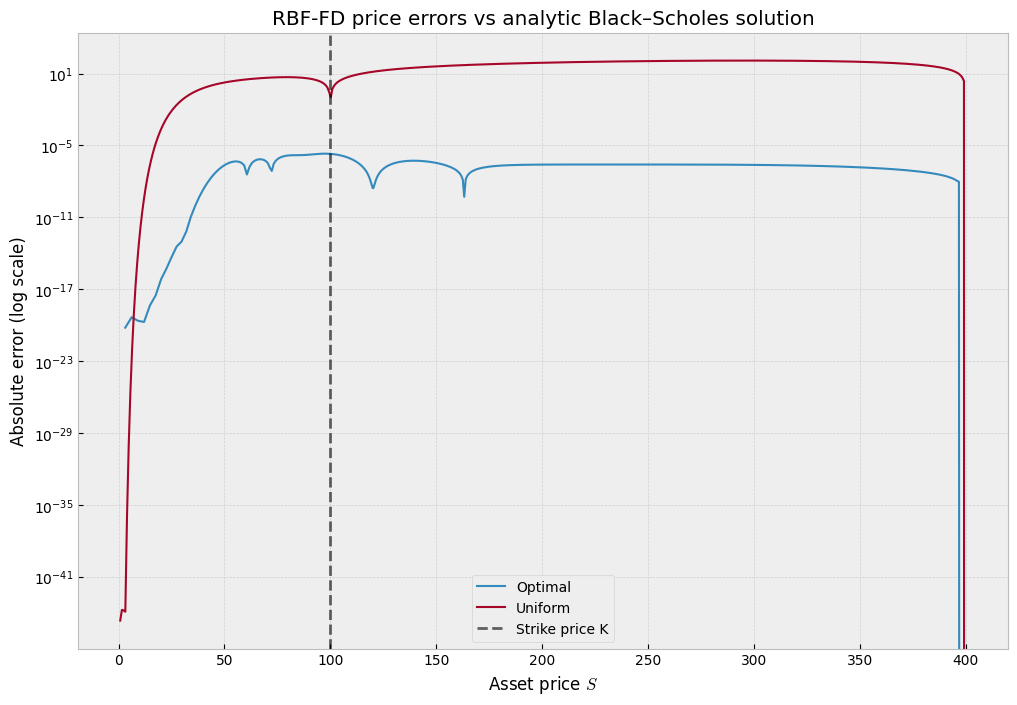

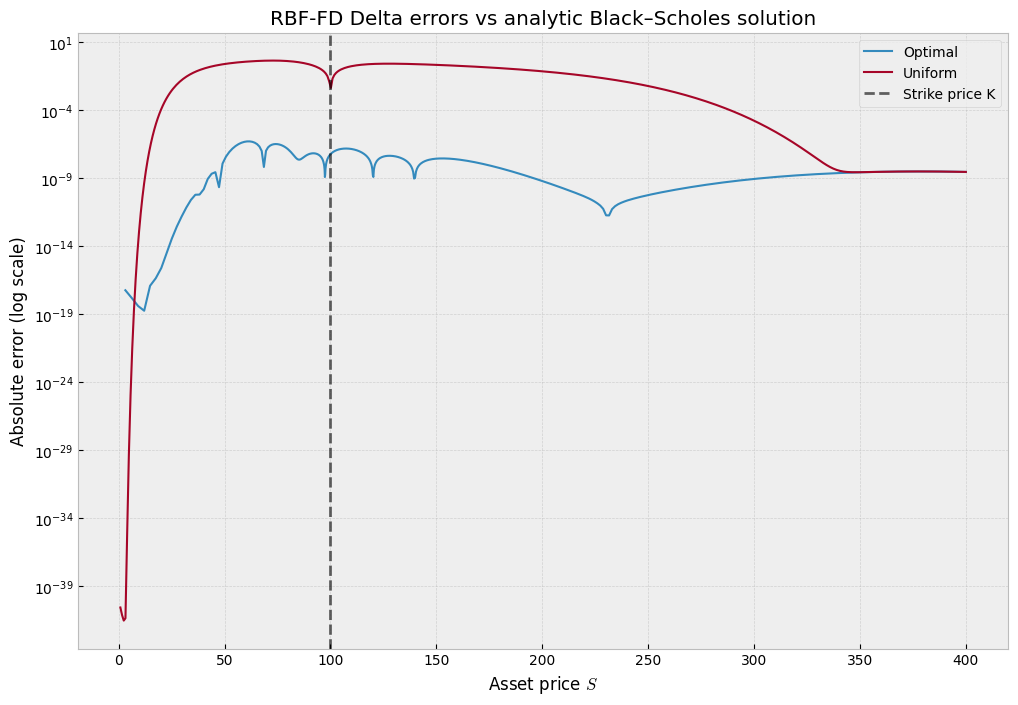

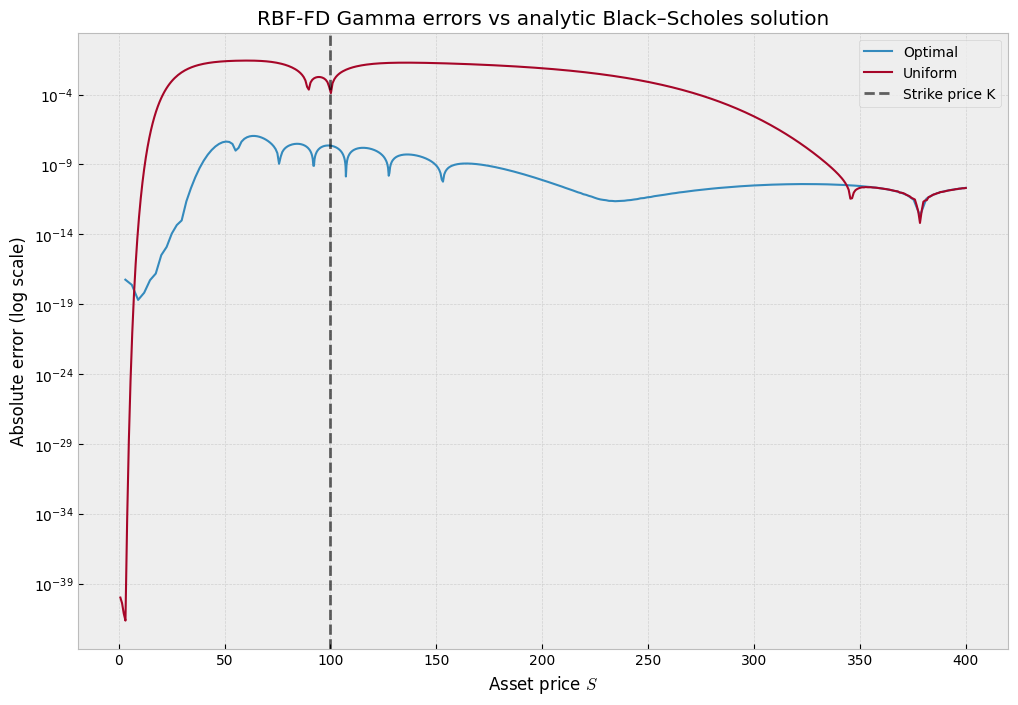

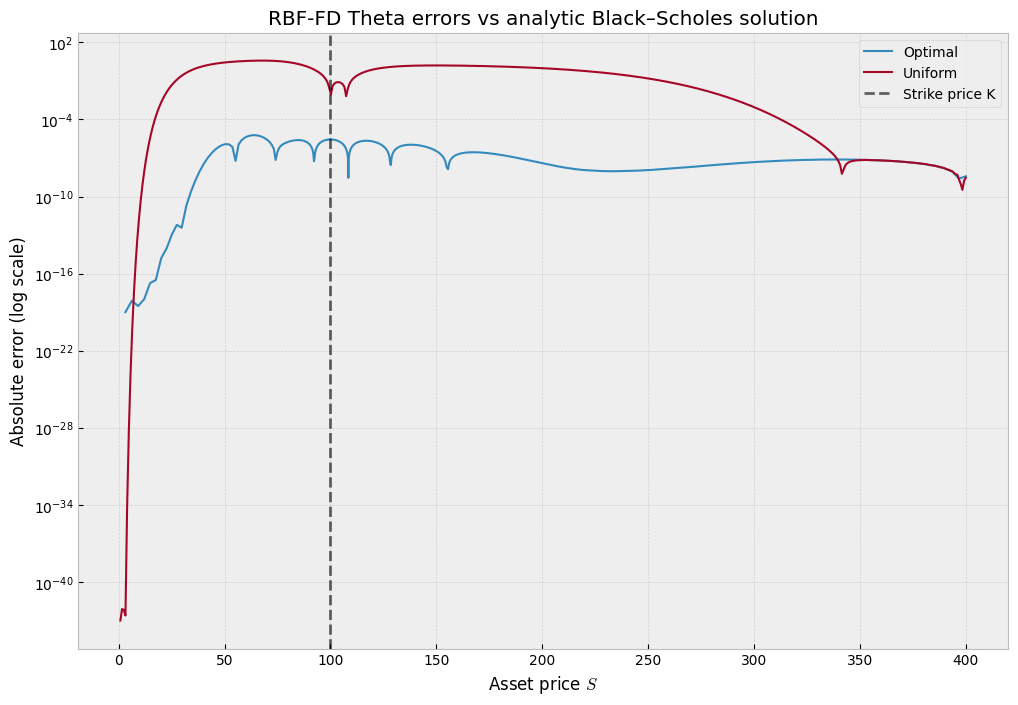

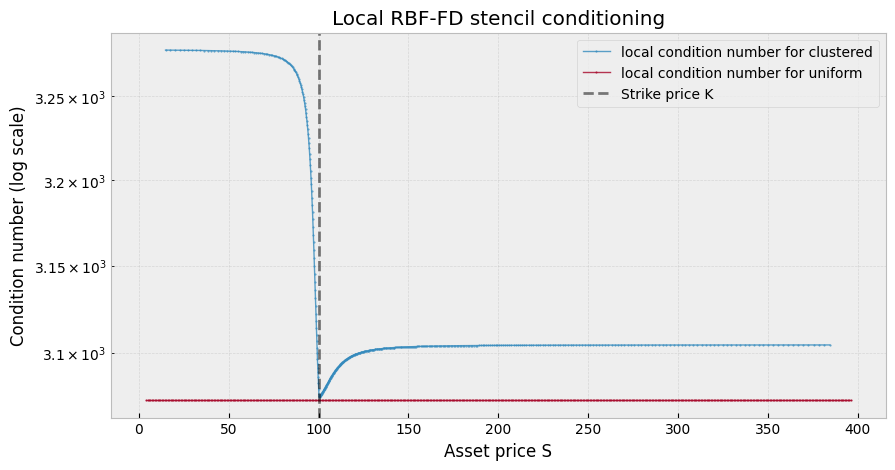

In [ ]:
plt.figure(figsize=(12, 8))
plt.semilogy(S_eval_c, price_error_c, label="Optimal", linewidth=1.5)
plt.semilogy(S_eval_u, price_error_u, label="Uniform", linewidth=1.5)
plt.axvline(K, color="k", linestyle="--", alpha=0.6, label="Strike price K")
plt.xlabel("Asset price $S$")
plt.ylabel("Absolute error (log scale)")
plt.title("RBF-FD price errors vs analytic Black\u2013Scholes solution")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 8))
plt.semilogy(S_eval_c, delta_error_c, label="Optimal", linewidth=1.5)
plt.semilogy(S_eval_u, delta_error_u, label="Uniform", linewidth=1.5)
plt.axvline(K, color="k", linestyle="--", alpha=0.6, label="Strike price K")
plt.xlabel("Asset price $S$")
plt.ylabel("Absolute error (log scale)")
plt.title("RBF-FD Delta errors vs analytic Black\u2013Scholes solution")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 8))
plt.semilogy(S_eval_c, gamma_error_c, label="Optimal", linewidth=1.5)
plt.semilogy(S_eval_u, gamma_error_u, label="Uniform", linewidth=1.5)
plt.axvline(K, color="k", linestyle="--", alpha=0.6, label="Strike price K")
plt.xlabel("Asset price $S$")
plt.ylabel("Absolute error (log scale)")
plt.title("RBF-FD Gamma errors vs analytic Black\u2013Scholes solution")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(12, 8))
plt.semilogy(S_eval_c, theta_error_c, label="Optimal", linewidth=1.5)
plt.semilogy(S_eval_u, theta_error_u, label="Uniform", linewidth=1.5)
plt.axvline(K, color="k", linestyle="--", alpha=0.6, label="Strike price K")
plt.xlabel("Asset price $S$")
plt.ylabel("Absolute error (log scale)")
plt.title("RBF-FD Theta errors vs analytic Black\u2013Scholes solution")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

cond_d1_c, cond_d2_c = collect_local_condition_numbers(S_nodes_clustered, m, k, p)
cond_d1_u, cond_d2_u = collect_local_condition_numbers(S_nodes_uniform, m, k, p)

plt.figure(figsize=(10, 5))
plt.semilogy(S_nodes_clustered[5:-5], cond_d1_c[5:-5], 'o-', label="local condition number for clustered", alpha=0.8, linewidth=1, markersize=0.5)
plt.semilogy(S_nodes_uniform[5:-5], cond_d1_u[5:-5], 'o-', label="local condition number for uniform", alpha=0.8, linewidth=1, markersize=0.5)
plt.axvline(K, color='k', linestyle='--', alpha=0.5, label="Strike price K")
plt.xlabel("Asset price S")
plt.ylabel("Condition number (log scale)")
plt.title("Local RBF-FD stencil conditioning")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()